In [4]:
import numpy as np

In [5]:
class KNearestNeighborsClassifier:

    def __init__(self, n_neighbors=5, random_state=42) -> None:

        np.random.seed(random_state)
        self.n_neighbors = n_neighbors

    
    def predict(self, X):

        X = X.reshape(-1, 1, X.shape[-1])

        distance = np.sqrt(np.square((self.x - X)).sum(axis=-1))
        argmn = np.argsort(distance, axis=1)
        kNeighbors_indices = argmn[:, :self.n_neighbors]
        kNeighbors_labels = self.y[kNeighbors_indices]

        return np.array([np.bincount(label).argmax() for label in kNeighbors_labels])
        

    def fit(self, X, y):

        self.x = X
        self.y = y

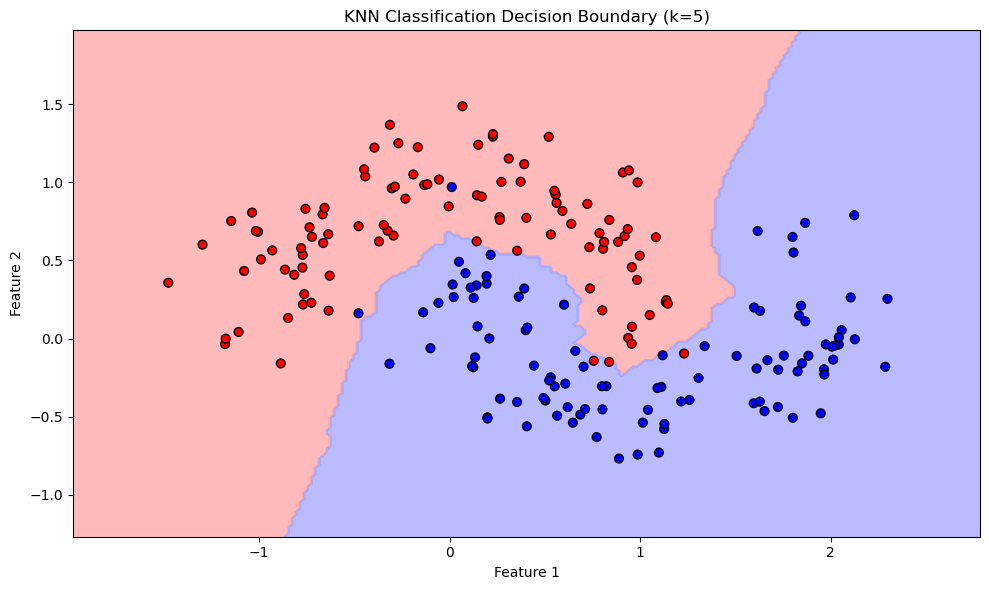

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons


X_train, y_train = make_moons(n_samples=200, noise=0.2, random_state=42)


clf = KNearestNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)


x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))


Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=40)

plt.title("KNN Classification Decision Boundary (k=5)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()